# Bayesian Optimization in SALSA: Support Vector Machines Hyperparameter Tuning

## Introduction to Bayesian Optimization

Bayesian Optimization refers to decision criteria for sequential selection and model updating con l'obiettivo di ottimizzare funzioni black-box (cioè funzioni di cui non conosciamo la forma analitica, e quindi non ne possiamo calcolare i gradienti o le Hessiane (derivative-free optimization), e che sono inoltre molto costose da valutare e quindi non ottimizzabili tramite "brute force")

Siamo interessati a trovare:

$$
x^* = \underset{x \in \mathcal{X}}{\operatorname{argmin}} f(x)
$$

dove $\mathcal{X}$ è di solito un iper-rettangolo, o un'altra semplice regione vincolata.  
Inoltre per il momento assumiamo che $f(x)$ sia deterministica e "well-behaved", ossia: continuous, relatively smooth, only real-valued inputs, etc.

The goal is simply to find the best input, $x$  minimizing $f$ , in the fewest number of evaluations.

Snoek et al. 2012 descrive perfettamente la differenza con gli altri metodi di ottimizzazione: "What makes Bayesian optimization different from other procedures is that it constructs a probabilistic model for $f(x)$ and then exploits this model to make decisions about where in $X$ to next evaluate the function, while integrating out uncertainty. The essential philosophy is to use all of the information available from previous evaluations of $f(x)$ and not simply rely on local gradient and Hessian approximations."

### Exploration-Exploitation Trade-off

Nella Bayesian Optimization dobbiamo continuamente bilanciare le seguenti due forze opposte:

1. **Exploitation**
Consiste nel favorire il campionamento nelle regioni in cui il GP stima che la media sia migliore (bassa se stiamo minimizzando o alta altrimenti). Il rischio è rimanere bloccati in minimi locali.

2. **Exploration**
Consiste nel favorire il campionamento nelle regioni in cui l'incertezza del GP è alta. Serve quindi per esplorare tutto lo spazio senza rimanere blocchati in minimi locali. Il rischio è quello di sprecare budget computazionale in zone dove la funzione non ha minimi (o massimi nel caso di massimizzazione). 

Cerchiamo una funzione di acquisizione, il cui compito sarà "guiderà" la scelta dei punti da campionare, che ponderi al meglio il trade-off tra exploration ed exploitation.

### Algoritmo (Single-Objective Sequential Bayesian Optimization):

**Inputs**

- $f(x)$ Funzione obiettivo (costosa)  
- $\mathcal{X}$ Spazio di ricerca  
- $N_{\text{max}}$ Budget di valutazioni  
- $N_0$ Dimensione del design iniziale  
- $\alpha(x; \mathcal{D})$ Funzione di acquisizione 

**Inizializzazione**

1. genera $\mathcal{D}_0 = \{(x_i, y_i)\}_{i=1}^{N_0}$ campionando $\mathcal{X}$ (es: LHS)  
2. Valuta $y_i = f(x_i)$ per ogni punto $x_i \in \mathcal{D}_0$

**for i in $N_0, \cdots, N_{\text{max}}$**

1. Fitta il GP sul dataset attuale $\mathcal{D_{t-1}}$ e ottimizza gli iperparametri $\theta$ e $\sigma_n^2$ (MLL)
2. Ottimizza l'acquisition function $\alpha(x)$, $x_{n+1} = \underset{x \in \mathcal{X}}{\operatorname{argmax}} \, \alpha(x; \mathcal{D}_{t-1})$
3. Valuta la funzione obiettivo nel punto selezionato: $y_t = f(x_t)$  
4. Aggiunge il punto al dataset $\mathcal{D}_t = \mathcal{D}_{t-1} \cup \{(x_t, y_t)\}$  

**Output**

Il punto ottimo trovato $x^* = \operatorname{argmin}_{x \in \mathcal{D}} y$ o la media del GP finale minimizzata.

In [39]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # active/
sys.path.insert(0, str(project_root))

from src.acquisition.bayesian_optimization.ei import ExpectedImprovement
from src.acquisition.bayesian_optimization.pi import ProbabilityOfImprovement
from src.acquisition.bayesian_optimization.ucb import UpperConfidenceBound
from src.evaluation.surrogate_evaluator import SurrogateEvaluator
from src.initial_design.lhs import LHS
from src.problems.monofidelity.branin import Branin
from src.sampler.experiment import Experiment
from src.sampler.generators.lhs import LHSCandidateGenerator
from src.surrogates.gaussianprocess import GaussianProcess
from src.visualization.bayesian_optimization_plots import BayesianOptimizationPlotter

### Improvement Utility (I(x))

$I(x)$ quantifica il guadagno effettivo che avremmo se campionassimo in un nuovo punto $x$ dato tutto quello che sappiamo fin ora riguardo ad $f$.

Sia $f^* = min_{i=1,\cdots,n} f(x_i)$ il miglior valore osservato fino ad ora:

$$
I(x) = max\{0, f^* - f(x)\}
$$

- Se $f(x) < f^*$, otteniamo un miglioramento positivo pari alla differenza $f^* - f(x)$  
- Se $f(x) \ge f^*$, il miglioramento è nullo (0)

### Upper Confidence Bound (UCB)

L'Upper Confidence Bound (UCB) è una delle funzioni di acquisizione più semplici, intuitive ed efficaci utilizzate nell'Ottimizzazione Bayesiana per bilanciare il bilancio tra exploitation ed exploration.

L'Upper Confidence Bound definisce l'utilità di campionare nel punto $x$ attraverso:

$$a_{	ext{UCB}}(x; \kappa) = \mu(x) + \kappa \cdot \sigma(x)$$

Dove $\mu(x)$ è termine di Exploitation, $\sigma(x)$ è il termine di Exploration e $\kappa \ge 0$ (oppure $\lambda$) è un iperparametro di bilanciamento impostato dall'utente.

C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as 

MSE: 401.97055462040066
RMSE: 20.049203341290163
MAE: 12.427690214899506


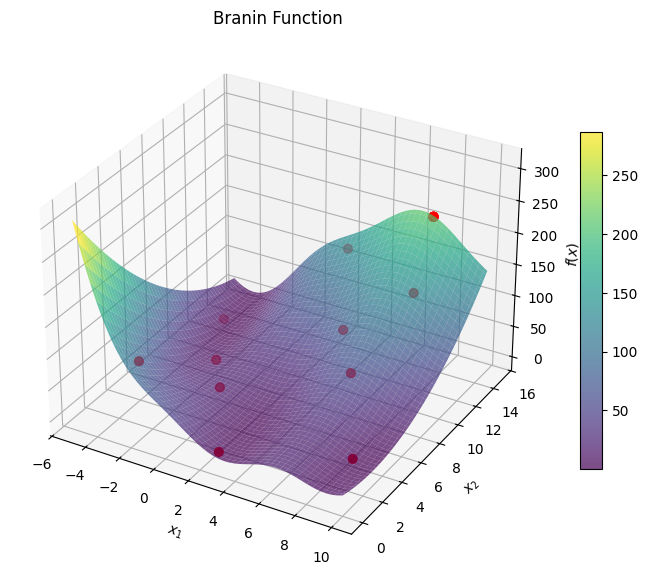

In [ ]:
problem = Branin() 

design = LHS(n_points=10)
dataset = design.generate(problem)

surrogate = GaussianProcess()

acquisition = UpperConfidenceBound(objective="maximize", w=0.5)
candidate_generator = LHSCandidateGenerator(n_points=1000)

evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)

result = experiment.run()

surrogate_final = result["surrogate"]
dataset_final = result["dataset"]
history = result["history"]

evaluation = evaluator.evaluate(surrogate_final)

print("MSE:",evaluation["mse"])
print("RMSE:",evaluation["rmse"])
print("MAE:",evaluation["mae"])

plotter = BayesianOptimizationPlotter(problem, surrogate=surrogate_final, history=history)
plotter.plot_surface(dataset_final.X, dataset_final.y)

### Probability Of Improvement (PI)

La Probability of Improvement (PI) calcola la probabilità pura che una nuova valutazione in un punto $x$ migliori il miglior risultato trovato fino a quel momento.  
PI misura quindi la probabilità che il valore reale $f(x)$ sia inferiore al massimo osservato fino a questo momento $f(x^+)$ (con un eventuale margine di miglioramento $\xi \ge 0$).  

La funzione di acquisizione è definita come:

$$a_{\text{PI}}(x) = P(f(x) \ge f(x^+) + \xi)$$

Trattandosi di una distribuzione normale per $\hat{f}(x)$, la probabilità si calcola analiticamente usando la funzione di ripartizione cumulativa (CDF) della distribuzione normale standard $\Phi(\cdot)$:

$$a_{\text{PI}}(x) = \Phi(Z)$$

Dove lo z-score $Z$ è definito come:

$$Z = \begin{cases} 
\frac{\mu(x) - f(x^+) - \xi}{\sigma(x)} & \text{se } \sigma(x) > 0 \\
0 & \text{se } \sigma(x) = 0 
\end{cases}$$


Naturalmente l'iperparametro $\xi$ gioca un ruolo fondamentale nel Trade-off Exploration/Exploitation. Per valori di $\xi$ prossimi a zero PI cercarà semplicemente un miglioramento minimo di qualunque entità campionando punti molto vicini al massimo attuale dove la deviazione standard $\sigma(x)$ è piccola ma la media $\mu(x)$ è alta, ignorando regioni sconosciute con $\sigma(x)$ grande. Al contrario per $\xi > 0$ si costringe l'algoritmo a cercare punti con un potenziale di guadagno più alto, favorendo quindi l'Exploration.


Il limite della PI(x) è chiaramente legato al fatto che, il prossimo punto campionato secondo questo criterio risulterebbe

$$
x_{n+1} = \underset{x}{\operatorname{argmax}} PI(x)
$$

ma questo non ci direbbe nulla sulla magnitudine del migliramento stesso. Un punto con un'altissima probabilità di migliorare di un valore infinitesimo verrà preferito a un punto incerto che potrebbe portare a un miglioramento enorme. la PI soffre quindi di eccessiva exploitation.

Per superare i limiti della PI ci rifacciamo al miglioramento atteso (EI)

MSE: 701.1875987283463
RMSE: 26.47994710584495
MAE: 14.528226716658502
Best found: 0.4018339244087148
Distance from minimun: 0.003946566678976637


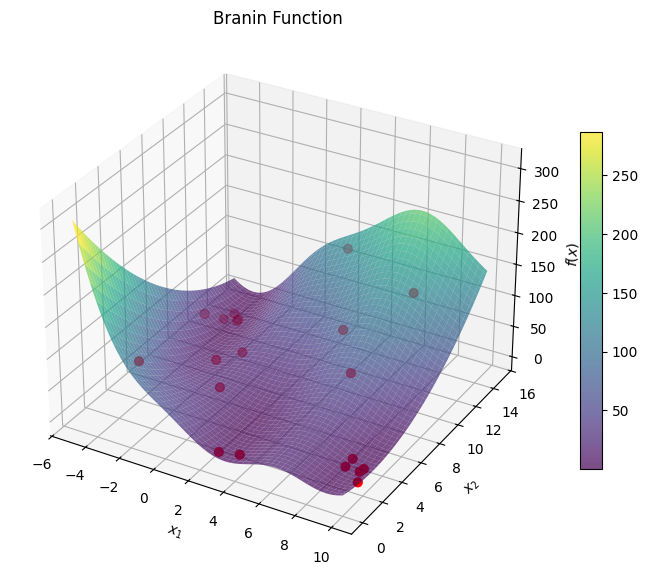

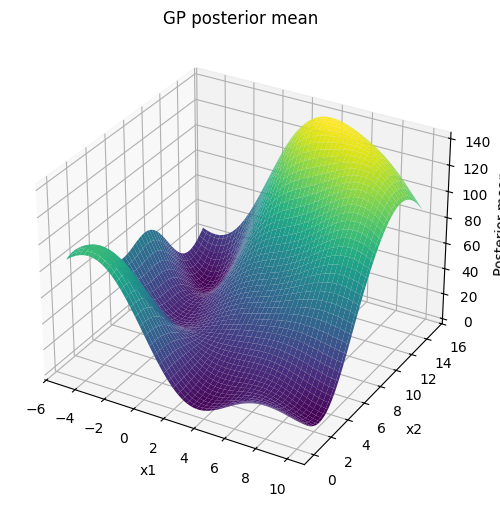

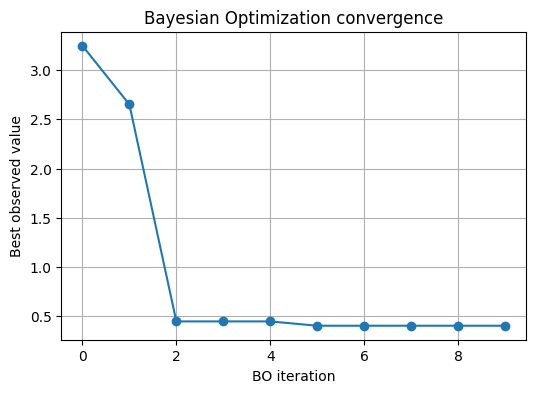

In [36]:
problem = Branin() 

design = LHS(n_points=10)
dataset = design.generate(problem)

surrogate = GaussianProcess()

acquisition = ProbabilityOfImprovement(objective="minimize")
candidate_generator = LHSCandidateGenerator(n_points=1000)

evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)

result = experiment.run()

surrogate_final = result["surrogate"]
dataset_final = result["dataset"]
history = result["history"]

best_values = [h["best_y"] for h in history]
best_value = history[-1]["best_y"]

evaluation = evaluator.evaluate(surrogate_final)

print("MSE:",evaluation["mse"])
print("RMSE:",evaluation["rmse"])
print("MAE:",evaluation["mae"])

print("Best found:", best_value)

if acquisition.objective == "minimize":
    print(f"Distance from minimun: {abs(problem.min - best_value)}")
else:
    print(f"Distance from maximun: {abs(problem.max - best_value)}")


plotter = BayesianOptimizationPlotter(problem, surrogate=surrogate_final, history=history)
plotter.plot_surface(dataset_final.X, dataset_final.y)
plotter.posterior_mean()
plotter.convergence_plot(best_values)

### Expected Improvement (EI)

L'Expected Improvement supera il limite della PI considerando sia la probabilità che la magnitudine del miglioramento calcolando il valore atteso dell'Improvement Utility $I(x)$:

$$
EI(x) = \mathbb{E}[I(x) | data] = \int_{-\infty}^{\infty} \max(0, \, y - f(x^+) - \xi) \, p(y \mid x) \, dy = (f^* - \mu_n(x)) \cdot \Phi(\frac{f^* - \mu_n(x)}{\sigma(x)}) + \sigma(x) \cdot \phi(\frac{f^* - \mu_n(x)}{\sigma(x)})
$$

Gestisce in automatico l'Exploration-Exploitation trade-off:

- $(f^* - \mu(x)) \cdot \Phi(Z)$ è grande quando la media stimata $\mu(x)$ è molto più bassa di $f^*$.
- $\sigma(x) \cdot \phi(Z)$ è grande quando l'incertezza $\sigma(x)$ attorno a $x$ è elevata.

MSE: 209.2128474324301
RMSE: 14.464191903885613
MAE: 10.53331441558349
Best found: 297.7433423642949
Distance from maximun: 10.385753962205115


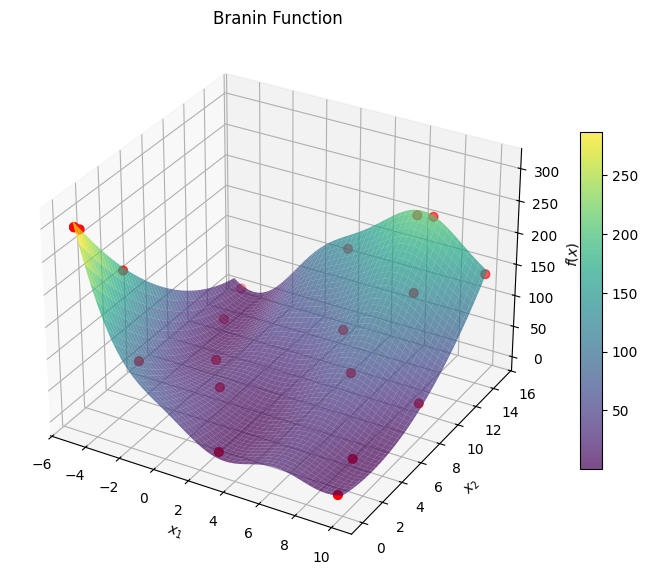

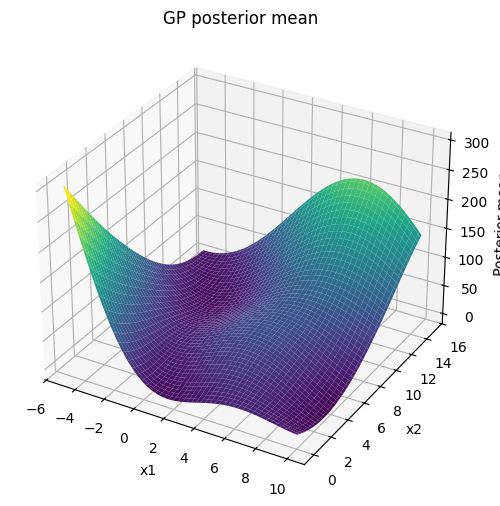

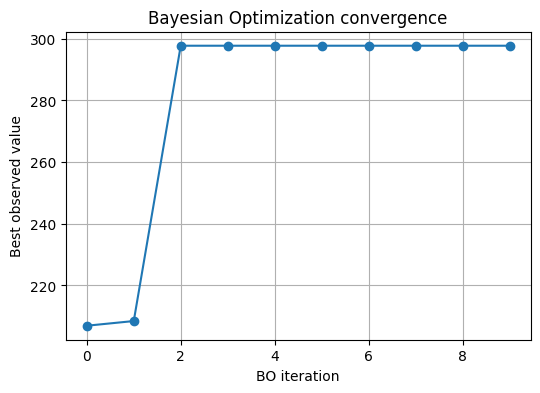

In [37]:
problem = Branin() 

design = LHS(n_points=10)
dataset = design.generate(problem)

surrogate = GaussianProcess()

acquisition = ExpectedImprovement(objective="maximize")
candidate_generator = LHSCandidateGenerator(n_points=1000)

evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)

result = experiment.run()

surrogate_final = result["surrogate"]
dataset_final = result["dataset"]
history = result["history"]

best_values = [h["best_y"] for h in history]
best_value = history[-1]["best_y"]

evaluation = evaluator.evaluate(surrogate_final)

print("MSE:", evaluation["mse"])
print("RMSE:", evaluation["rmse"])
print("MAE:", evaluation["mae"])

print("Best found:", best_value)

if acquisition.objective == "minimize":
    print(f"Distance from minimun: {abs(problem.min - best_value)}")
else:
    print(f"Distance from maximun: {abs(problem.max - best_value)}")


plotter = BayesianOptimizationPlotter(problem, surrogate=surrogate_final, history=history)
plotter.plot_surface(dataset_final.X, dataset_final.y)
plotter.posterior_mean()
plotter.convergence_plot(best_values)

### 